In [2]:
import warnings


In [3]:
from pathlib import Path
import os

IMAGES_PATH = Path("../resources/cloud-images/cloud-classifier-1")

def index_labeled_images(images_path=IMAGES_PATH):
    cloud_labels = []
    images_path = Path(images_path)
    labeled_images = {}
    if not images_path.exists():
        return labeled_images, cloud_labels

    for cloud_dir in sorted(p for p in images_path.iterdir() if p.is_dir()):
        cloud_labels.append(cloud_dir.name)
        for img_path in sorted(p for p in cloud_dir.iterdir() if p.is_file()):
            labeled_images[img_path.name] = {
                "label": cloud_dir.name,
                "path": str(img_path)
            }

    return labeled_images, cloud_labels

In [4]:
labeled_images, cloud_labels = index_labeled_images()

In [5]:
print(len(labeled_images))

698


In [6]:
import os
import matplotlib.pyplot as plt
import numpy as np
import cv2
from tqdm.auto import tqdm

def extract_labels(labeled_images):
    import os  # Ensure os is imported for path validation
    images = []
    labels = []
    for (i, image_name) in tqdm(enumerate(labeled_images), total=len(labeled_images)):
        path = labeled_images[image_name]['path']

        # Check if the file exists before attempting to read
        if not os.path.exists(path):
            print(f"Error: File does not exist at path: {path}")
            continue

        # Attempt to read the image
        image = cv2.imread(path)
        if image is None:
            print(f"Error: Unable to read image at path: {path}")
            continue

        try:
            # Convert to grayscale and resize
            image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
            image = cv2.resize(image, (128, 128))
            images.append(image)

            # Append the label
            label = labeled_images[image_name]['label']
            labels.append(label)
        except Exception as e:
            print(f"Error processing image {image_name}: {e}")
            continue

    return np.array(images), np.array(labels)

/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
images, labels = extract_labels(labeled_images)

100%|██████████| 698/698 [00:00<00:00, 1112.27it/s]


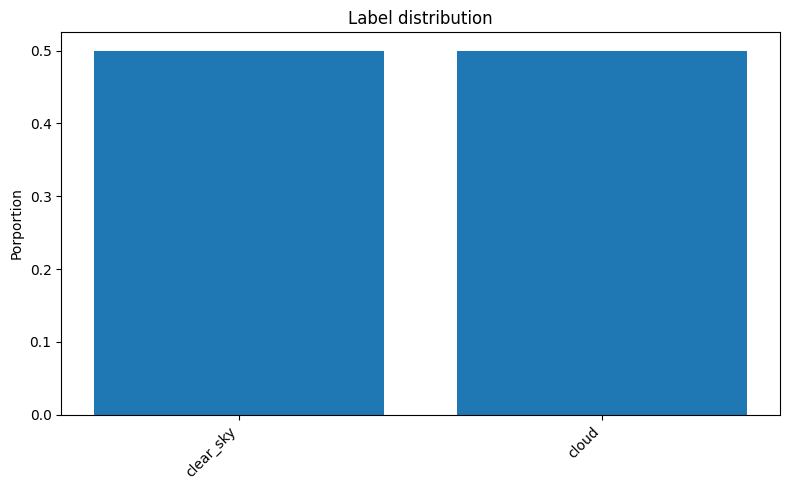

In [8]:
import matplotlib.pyplot as plt
from collections import Counter

# labels must be a 1D array or list of class names
label_counts = Counter(labels)
classes = list(label_counts.keys())
counts = np.array(list(label_counts.values()))
props = counts / counts.sum()

plt.figure(figsize=(8, 5))
plt.bar(classes, props)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Porportion")
plt.title("Label distribution")
plt.tight_layout()
plt.show()

In [9]:
print(props)

[0.5 0.5]


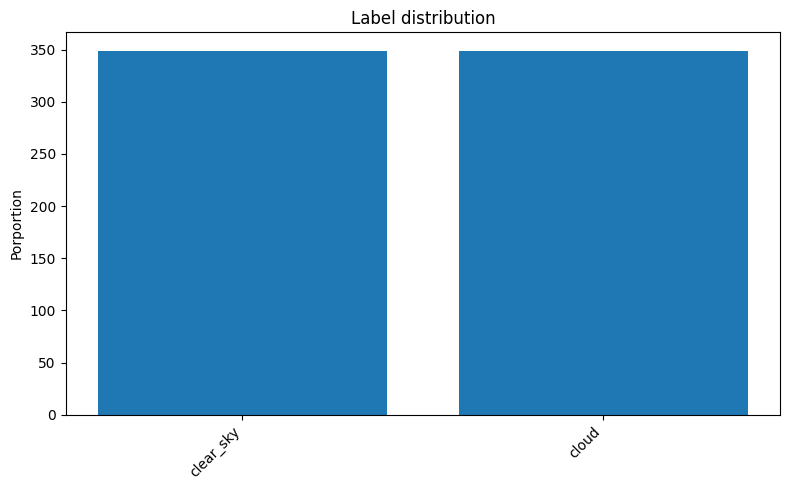

In [10]:
import matplotlib.pyplot as plt
from collections import Counter

# labels must be a 1D array or list of class names
label_counts = Counter(labels)
classes = list(label_counts.keys())
counts = np.array(list(label_counts.values()))

plt.figure(figsize=(8, 5))
plt.bar(classes, counts)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Porportion")
plt.title("Label distribution")
plt.tight_layout()
plt.show()

In [11]:
print(counts)

[349 349]


In [12]:
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import LabelEncoder

ordinal_encoder = LabelEncoder()
labels_encoded = ordinal_encoder.fit_transform(labels)

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(sss.split(images, labels_encoded))

X_train, X_test = images[train_idx], images[test_idx]
y_train, y_test = labels_encoded[train_idx], labels_encoded[test_idx]

print("train:", X_train.shape, y_train.shape)
print("test: ", X_test.shape, y_test.shape)

train: (558, 128, 128) (558,)
test:  (140, 128, 128) (140,)


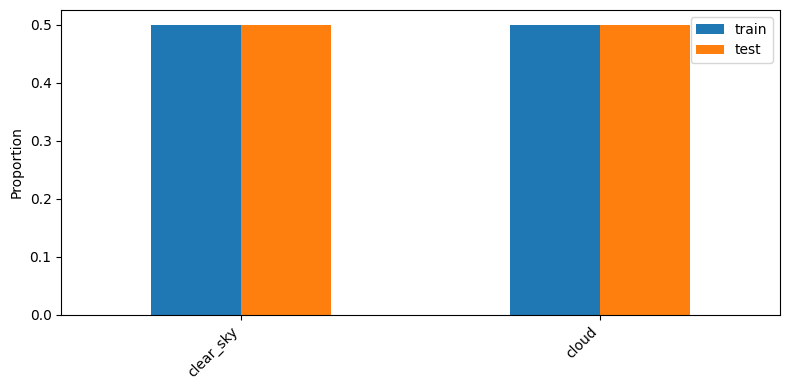

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

train_props = pd.Series(ordinal_encoder.inverse_transform(y_train)).value_counts(normalize=True)
test_props  = pd.Series(ordinal_encoder.inverse_transform(y_test)).value_counts(normalize=True)

df = pd.DataFrame({"train": train_props, "test": test_props}).fillna(0).reindex(ordinal_encoder.classes_)

df.plot(kind="bar", figsize=(8,4))
plt.ylabel("Proportion")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

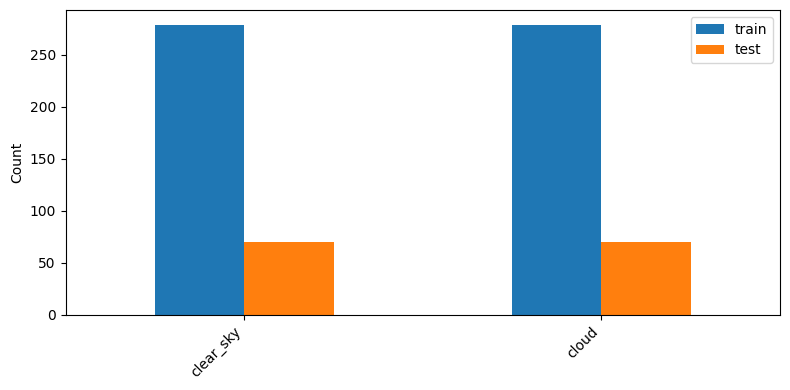

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# inverse_transform returns shape (n_samples, 1) for many encoders -> flatten to 1D
train_labels = ordinal_encoder.inverse_transform(y_train).ravel()
test_labels  = ordinal_encoder.inverse_transform(y_test).ravel()

train_counts = pd.Series(train_labels).value_counts()        # <- absolute counts
test_counts  = pd.Series(test_labels).value_counts()

df = (pd.DataFrame({"train": train_counts, "test": test_counts}).fillna(0).astype(int).reindex(ordinal_encoder.classes_, fill_value=0))

ax = df.plot(kind="bar", figsize=(8,4))
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [15]:
print(X_train[0])
print(type(y_train))

[[132 132 132 ... 129 129 129]
 [134 134 134 ... 128 129 129]
 [137 137 136 ... 129 129 129]
 ...
 [172 172 173 ... 180 180 180]
 [173 173 173 ... 180 180 180]
 [174 174 174 ... 180 180 180]]
<class 'numpy.ndarray'>


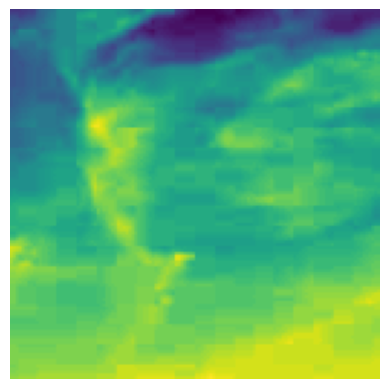

In [16]:
import matplotlib.pyplot as plt
import torch
from PIL import Image
import torchvision.transforms as transforms

img_tensor = torch.from_numpy(X_train[0])

def plot_image(image):
    plt.imshow(image)
    plt.axis("off")

plot_image(img_tensor)
plt.show()

In [17]:
# augmentation

import torch
import torchvision.transforms.v2 as T
from torchvision.transforms.v2 import InterpolationMode

def color_jitter_if_rgb(x):
    return T.ColorJitter(brightness=0.20, contrast=0.20, saturation=0.15, hue=0.02)(x) if x.ndim == 3 and x.shape[0] == 3 else x

IMG_SIZE = (128, 128)
MAX_FRAC = 0.14

# translation with black borders
border_translation = T.RandomAffine(
    degrees=0,
    translate=(MAX_FRAC, MAX_FRAC),
    interpolation=InterpolationMode.BILINEAR,
    fill=0
)

# translation with wrap/repeat
wrap_translation = T.Lambda(lambda x: torch.roll(
    x,
    shifts=(
        int(torch.randint(-int(MAX_FRAC * x.shape[-2]), int(MAX_FRAC * x.shape[-2]) + 1, (1,)).item()),  # dy
        int(torch.randint(-int(MAX_FRAC * x.shape[-1]), int(MAX_FRAC * x.shape[-1]) + 1, (1,)).item()),  # dx
    ),
    dims=(-2, -1),
))

# stacked pipeline
stacked = T.Compose([
    T.RandomChoice([wrap_translation, border_translation]),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.15),
    T.RandomAffine(
        degrees=20,
        scale=(0.90, 1.10),
        interpolation=InterpolationMode.BILINEAR,
        fill=0
    ),
    T.RandomResizedCrop(
        size=IMG_SIZE,
        scale=(0.80, 1.00),
        ratio=(0.90, 1.10),
        interpolation=InterpolationMode.BILINEAR
    ),
    # T.ColorJitter(brightness=0.20, contrast=0.20, saturation=0.15, hue=0.02),
])

# one of pipeline
one_of = T.RandomChoice([
    wrap_translation,
    border_translation,
    T.RandomChoice([
        T.RandomHorizontalFlip(p=1.0),
        T.RandomVerticalFlip(p=1.0),
    ]),
    T.RandomRotation(degrees=20, interpolation=InterpolationMode.BILINEAR, fill=0),
    # T.ColorJitter(brightness=0.20),
    # T.ColorJitter(contrast=0.20),
    # T.ColorJitter(saturation=0.15),
])

# alternating between modes
augmentation_transform = T.Compose([
    T.Resize(IMG_SIZE),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.RandomChoice([stacked, one_of]),
])

In [18]:
print(img_tensor.shape, img_tensor.dtype)

torch.Size([128, 128]) torch.uint8


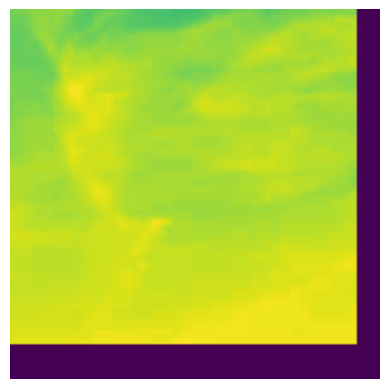

In [19]:
augmented_img = augmentation_transform(img_tensor.unsqueeze(0))
plt.imshow(augmented_img.squeeze(0))  # (64,64)
plt.axis("off")
plt.show()


In [20]:
print("Classes:", ordinal_encoder.classes_)
print("\nTrain label distribution:")
for label in ordinal_encoder.classes_:
    idx = ordinal_encoder.transform([label])[0]
    count = int(np.sum(y_train == idx))
    print(f"  {label} (index {idx}): {count}")

Classes: ['clear_sky' 'cloud']

Train label distribution:
  clear_sky (index 0): 279
  cloud (index 1): 279


In [21]:
import numpy

# Target number of training images per class after augmentation
target_count_per_class = 2400

y_train_augmented_images = []
X_train_augmented_images = []

for class_idx in range(len(ordinal_encoder.classes_)):
    class_name = ordinal_encoder.classes_[class_idx]
    class_count = int(np.sum(y_train == class_idx))
    multiple = target_count_per_class // class_count
    print(f"{class_name} (index {class_idx}): {class_count} images, augmenting x{multiple - 1}")

    for i in range(len(y_train)):
        if y_train[i] == class_idx:
            for j in range(int(multiple) - 1):
                img_torch = torch.from_numpy(X_train[i])
                augmented_img = augmentation_transform(img_torch.unsqueeze(0))
                squeezed_img = augmented_img.squeeze(0)
                X_train_augmented_images.append(squeezed_img.numpy())
                y_train_augmented_images.append(class_idx)

print(f"\nTotal augmented images added: {len(y_train_augmented_images)}")

clear_sky (index 0): 279 images, augmenting x7
cloud (index 1): 279 images, augmenting x7

Total augmented images added: 3906


In [22]:
print(len(y_train_augmented_images))

3906


In [23]:
y_train_with_augmented_images = np.concatenate((y_train, y_train_augmented_images))
X_train_with_augmented_images = np.concatenate((X_train, X_train_augmented_images))

In [24]:
print(y_train_with_augmented_images.shape, X_train_with_augmented_images.shape)


(4464,) (4464, 128, 128)


In [25]:
import numpy as np

# Create a permuted list of indices
indices = np.random.permutation(len(y_train_with_augmented_images))

# Reorder both arrays using those indices
X_train_with_augmented_images = X_train_with_augmented_images[indices]
y_train_with_augmented_images = y_train_with_augmented_images[indices]


[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
0


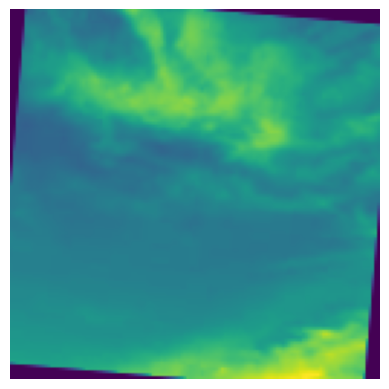

In [26]:
print(X_train_with_augmented_images[2])

plot_image(X_train_with_augmented_images[2])
print(y_train_with_augmented_images[2])

/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_label.py:151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_label.py:151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


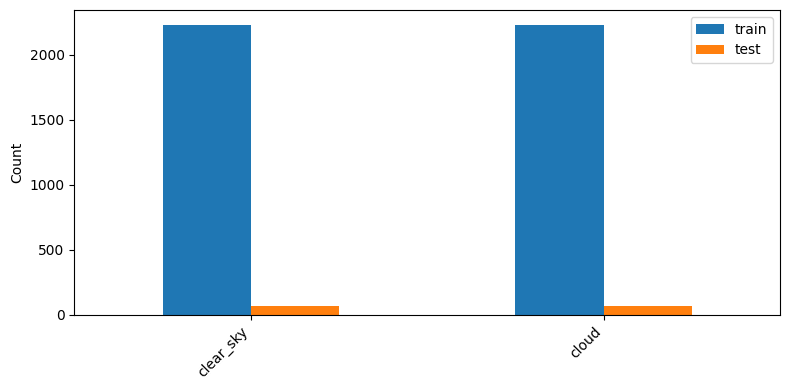

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

ytr = pd.Series(y_train_with_augmented_images).to_numpy().reshape(-1, 1)
yte = pd.Series(y_test).to_numpy().reshape(-1, 1)

train_labels = ordinal_encoder.inverse_transform(ytr).ravel()
test_labels  = ordinal_encoder.inverse_transform(yte).ravel()

train_counts = pd.Series(train_labels).value_counts()
test_counts  = pd.Series(test_labels).value_counts()

df = (pd.DataFrame({"train": train_counts, "test": test_counts})
        .reindex(ordinal_encoder.classes_, fill_value=0)
        .astype(int))

ax = df.plot(kind="bar", figsize=(8,4))
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [28]:
print("train:", X_train_with_augmented_images.shape, y_train_with_augmented_images.shape)
print("test: ", X_test.shape, y_test.shape)

train: (4464, 128, 128) (4464,)
test:  (140, 128, 128) (140,)


In [29]:
X_train_flat = X_train_with_augmented_images.reshape(len(X_train_with_augmented_images), -1)
X_test_flat  = X_test.reshape(len(X_test), -1)

In [30]:
print(X_train_flat.shape)
print(X_test_flat.shape)

(4464, 16384)
(140, 16384)


In [31]:
def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())

In [32]:
from sklearn.metrics import precision_score, recall_score, f1_score

def display_clf_scores(labels, predictions):
    precision = precision_score(labels, predictions)
    recall = recall_score(labels, predictions)
    f1 = f1_score(labels, predictions)

    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)


In [36]:
import numpy as np
import torch
from sklearn.base import BaseEstimator, ClassifierMixin

class AugmentingClassifier(BaseEstimator, ClassifierMixin):
    """
    Wraps any sklearn classifier so that augmentation happens *inside* fit() only.
    Validation folds always see unaugmented originals — no leakage.
    """
    def __init__(self, base_clf=None, target_count=2400, random_state=42):
        self.base_clf = base_clf
        self.target_count = target_count
        self.random_state = random_state

    def _augment(self, X, y):
        X_extra, y_extra = [], []
        for cls in np.unique(y):
            cls_imgs = X[y == cls]
            multiple = self.target_count // len(cls_imgs)
            for img in cls_imgs:
                img_torch = torch.from_numpy(img)
                for _ in range(multiple - 1):
                    aug = augmentation_transform(img_torch.unsqueeze(0)).squeeze(0).numpy()
                    X_extra.append(aug)
                    y_extra.append(cls)

        X_norm = X.astype(np.float32) / 255.0
        if X_extra:
            X_all = np.concatenate([X_norm, np.stack(X_extra)])
            y_all = np.concatenate([y, np.array(y_extra)])
        else:
            X_all, y_all = X_norm, y

        rng = np.random.RandomState(self.random_state)
        idx = rng.permutation(len(X_all))
        return X_all[idx], y_all[idx]

    def fit(self, X, y):
        X_aug, y_aug = self._augment(X, y)
        self.base_clf.fit(X_aug.reshape(len(X_aug), -1), y_aug)
        return self

    def predict(self, X):
        X_norm = X.astype(np.float32) / 255.0
        return self.base_clf.predict(X_norm.reshape(len(X_norm), -1))

    def predict_proba(self, X):
        X_norm = X.astype(np.float32) / 255.0
        return self.base_clf.predict_proba(X_norm.reshape(len(X_norm), -1))

In [37]:
from typing import Dict, Any
import time
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier


def get_default_classifiers(random_state: int = 42) -> Dict[str, Any]:
    """
    Return a dictionary of main classification models (some with scaling).
    """
    return {
        # "gaussian_nb": GaussianNB(),
        "log_reg": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=1000, random_state=random_state))
        ]),
        "linear_svc": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SGDClassifier(loss="hinge", random_state=random_state))
        ]),
        # "svc_rbf": Pipeline([
        #     ("scaler", StandardScaler()),
        #     ("clf", SVC(kernel="rbf", probability=True, random_state=random_state))
        # ]),
        "knn": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier())
        ]),
        # "decision_tree": DecisionTreeClassifier(random_state=random_state),
        "random_forest": RandomForestClassifier(random_state=random_state),
        # "gradient_boosting": GradientBoostingClassifier(random_state=random_state,
        #                                                 n_estimators=150,
        #                                                 learning_rate=0.1,
        #                                                 max_depth=3,
        #                                                 subsample=0.7
        #                                                 ),
        # "hist_gradient_boosting": HistGradientBoostingClassifier(random_state=random_state),
        "mlp": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", MLPClassifier(max_iter=500, random_state=random_state))
        ])
    }


def evaluate_classifiers(X, y, scoring: str = "f1_macro", cv: int = 3,
                         n_jobs: int = -1, random_state: int = 42,
                         verbose: int = 1
) -> pd.DataFrame:
    """
    Evaluate many classification models with default hyperparameters.
    Augmentation is applied inside each CV fold via AugmentingClassifier — no leakage.
    X should be original (non-augmented) images of shape (n, H, W).
    Returns a sorted dataframe of cross-validation results.
    """
    classifiers = get_default_classifiers(random_state)
    cv_obj = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)

    results = []

    for name, clf in tqdm(classifiers.items(), total=len(classifiers.items())):
        if verbose:
            print(f"\nEvaluating model: {name}")

        t0 = time.perf_counter()

        scores = cross_val_score(
            AugmentingClassifier(base_clf=clf), X, y,
            scoring=scoring,
            cv=cv_obj,
            n_jobs=n_jobs
        )

        t1 = time.perf_counter()

        results.append({
            "model": name,
            "mean_score": np.mean(scores),
            "std_score": np.std(scores),
            "time_elapsed": t1 - t0
        })

    return pd.DataFrame(results).sort_values("mean_score", ascending=False)

In [38]:
results = evaluate_classifiers(X_train, y_train, scoring="f1_macro", cv=5)
print(results)

  0%|          | 0/5 [00:00<?, ?it/s]


Evaluating model: log_reg


/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200


Evaluating model: linear_svc


/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: 

...


Evaluating model: random_forest


 80%|████████  | 4/5 [01:47<00:28, 28.64s/it]


Evaluating model: mlp


/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: 

           model  mean_score  std_score  time_elapsed
3  random_forest    0.937215   0.023514     48.498750
4            mlp    0.874984   0.046642     29.419746
0        log_reg    0.657389   0.015962     40.295310
1     linear_svc    0.633641   0.032223     15.172118
2            knn    0.534668   0.009311      3.973562


In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_flat, y_train_with_augmented_images)

X_test_flat = X_test.reshape(len(X_test), -1)
y_pred = rf.predict(X_test_flat)

print("=== Held-out test set results ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1:        {f1_score(y_test, y_pred):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=ordinal_encoder.classes_))

=== Held-out test set results ===
Accuracy:  0.9429
Precision: 0.9306
Recall:    0.9571
F1:        0.9437

              precision    recall  f1-score   support

   clear_sky       0.96      0.93      0.94        70
       cloud       0.93      0.96      0.94        70

    accuracy                           0.94       140
   macro avg       0.94      0.94      0.94       140
weighted avg       0.94      0.94      0.94       140

